In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy.stats as stats
import math
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

c:\Users\Pc\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
train = pd.read_csv(r'C:\Users\Pc\Desktop\anadolu-hayat-emeklilik-datathon-2024\train.csv')

In [3]:
test = pd.read_csv(r'C:\Users\Pc\Desktop\anadolu-hayat-emeklilik-datathon-2024\test.csv')

In [5]:
def general_specs(df):
    print('*'*25,'SHAPE','*'*25)
    print(df.shape)
    print('*'*25,'INFO','*'*25)
    print(df.info())
    print('*'*25, 'NUMERICAL COLUMNS', '*'*25)
    display(describe(df, numerical = True))
    print('*'*25, 'CATEGORICAL COLUMNS','*'*25)
    display(describe(df, numerical = False))        # display daha detaylı gösteriyor

In [6]:
def describe(df, numerical):
    if numerical:
        describe_df = df.describe()
        numerical_columns = describe_df.columns         # describe defaultu numeric döndürüyor direk bu şekilde çekilebilir
        df_numerical = df.loc[:,numerical_columns]
        describe_T = describe_df.T
        missing_values = pd.DataFrame(data = df_numerical.isnull().sum(), columns = ['Miss_values'])
        describe_T['Missing_values'] = missing_values
        skewness = pd.DataFrame(data = df_numerical.skew().T, columns = ['Skewness'])     
        kurtosis = pd.DataFrame(data = df_numerical.kurtosis().T, columns = ['Kurtosis'])
        return pd.concat([describe_T, skewness, kurtosis], axis = 1)
    else:
        describe_df = df.describe(exclude = np.number).T
        describe_df['Missing Values'] = df.loc[:,describe_df.index].isnull().sum()
        return describe_df
    
    # Skewness measures the asymmetry of the distribution. Positive skewness indicates a distribution with a long right tail, while negative skewness indicates a long left tail. 
    # A skewness close to 0 suggests a symmetrical distribution.
    # Kurtosis measures the "tailedness" of the distribution. High kurtosis indicates heavy tails or outliers, while low kurtosis indicates light tails. 
    # A kurtosis value of 0 suggests a normal distribution (excess kurtosis of 0), while values greater than 0 indicate heavy tails and values less than 0 indicate light tails.


In [7]:
def categorical_examiner(df, col, colors_set = 0, rotation = False):
    df = df.sort_values(by = col, ascending = False)
    unique_rows = df[col].nunique()
    palette = 'tab10'
    if unique_rows > 10:
        palette = 'tab20'
    colors = sns.color_palette(palette=palette, n_colors=unique_rows)
    f, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(12,6))
    sns.countplot(df, x = col, palette = colors, ax = ax[0])
    sns.countplot(df.loc[df['LABEL'] != 'UA'], x = col, palette = colors[colors_set:], ax = ax[1])
    ax[0].set_title('UA DAHİL')
    ax[1].set_title('UA HARİÇ')
    plt.suptitle(f'COL:{col} COUNT PLOT')
    if rotation == True:
        ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
        ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
    plt.tight_layout()
    return plt.show()

In [8]:
def numerical_examiner(df, col, log = True, bins = 100):
    nrows = 1
    if log == True:
        nrows = 2
        temp_df = df.copy()
        temp_df[col] = temp_df[col].apply(np.log10)
        temp_df[col] = temp_df[col].replace(-np.inf, 0)
        temp_df[col] = temp_df[col].replace(np.nan, 0)
    f, ax = plt.subplots(nrows = nrows, ncols = 2, figsize=(12,6*nrows))
    if log == True:
        ax11, ax12, ax21, ax22 = ax[0][0], ax[0][1], ax[1][0], ax[1][1]
    else:
        ax11, ax12 = ax[0], ax[1]      
    sns.histplot(df, x = col, bins = bins, ax = ax11)
    sns.boxplot(df, x = col, ax = ax12)
    ax11.set_title('Histogram')
    ax12.set_title('Boxplot')
    if log == True:
        sns.histplot(temp_df, x=col, bins = bins, ax=ax21)
        sns.boxplot(temp_df, x = col, ax = ax22 )
        ax21.set_title('LOG10 HISTOGRAM')
        ax22.set_title('LOG10 Boxplot')
    plt.suptitle(f'Column:{col}, MIN:{df[col].min()}, MAX:{df[col].max()}')
    plt.tight_layout()
    return plt.show()

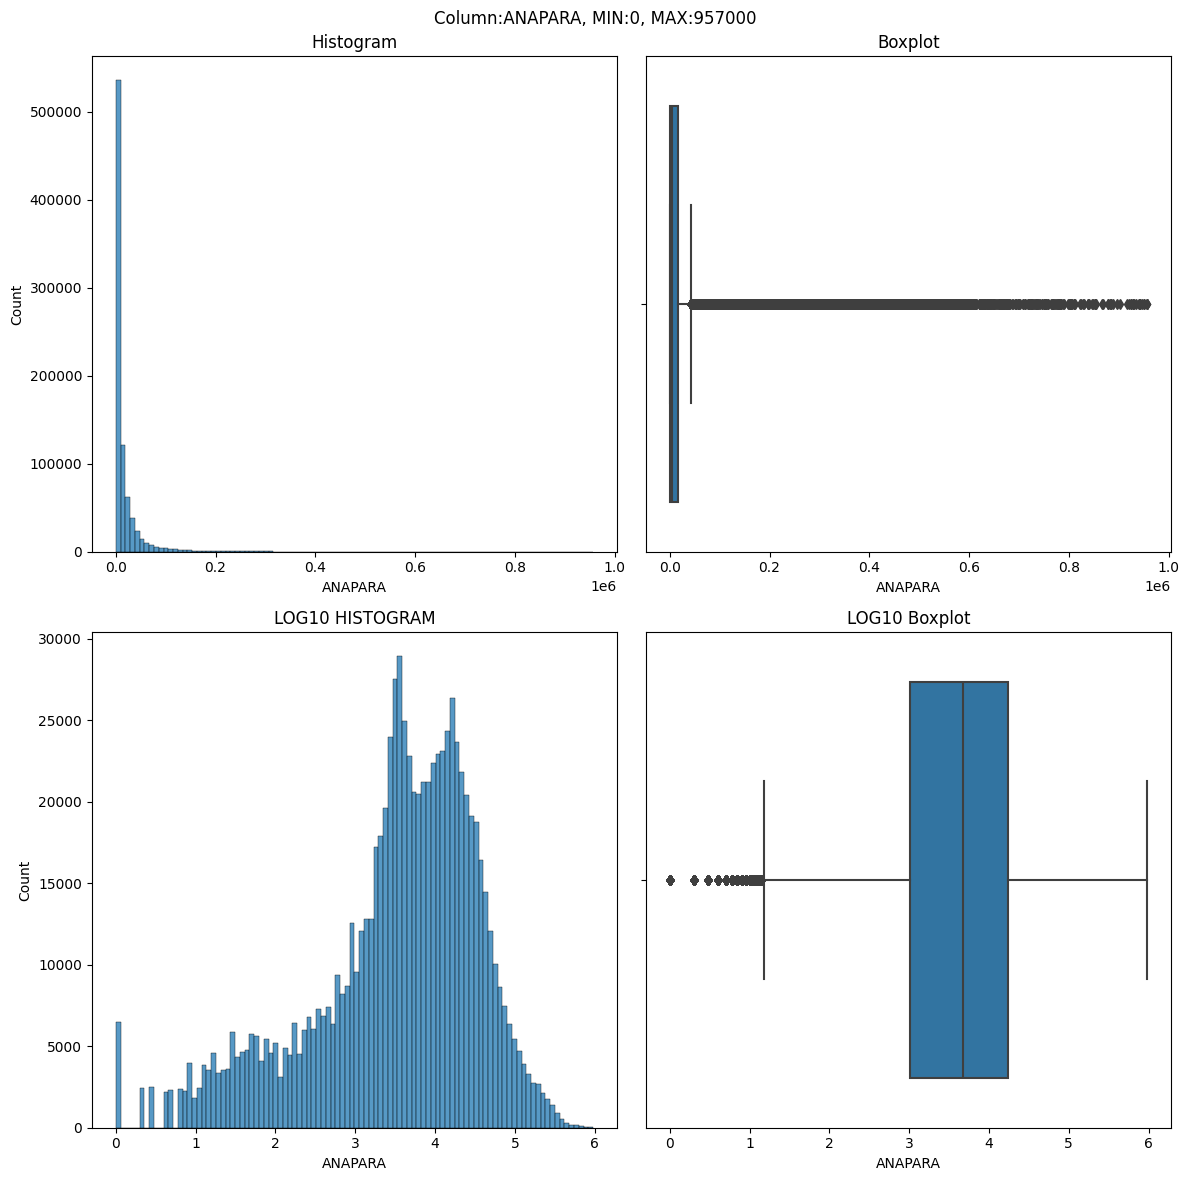

In [7]:
numerical_examiner(train, 'ANAPARA')

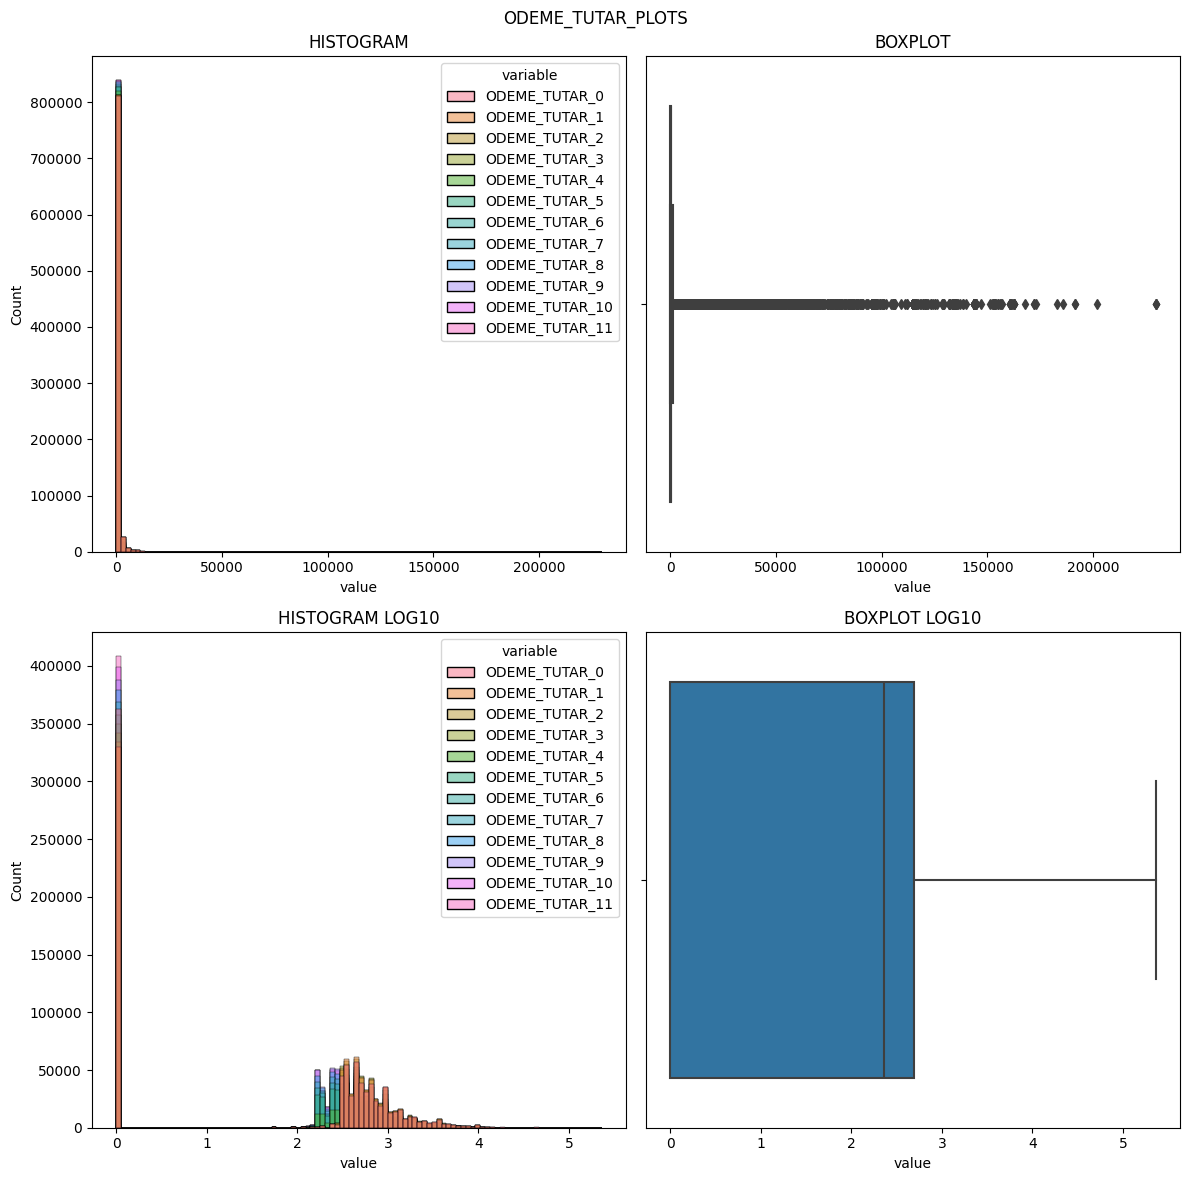

In [4]:
colors = sns.color_palette(n_colors=12)
cols = ["ODEME_TUTAR_" + str(i) for i in range(12)]
bins=100
temp_df = train.copy()
for col in cols:
    temp_df[col] = temp_df[col].apply(np.log10)
    temp_df[col] = temp_df[col].replace(-np.inf,0)
    temp_df[col] = temp_df[col].replace(-np.nan,0)
temp_train = pd.melt(train, value_vars=cols)
temp_df = pd.melt(temp_df, value_vars = cols )
f, ax = plt.subplots( nrows = 2, ncols = 2, figsize = (12,12))
ax11, ax12, ax21, ax22 = ax[0][0], ax[0][1], ax[1][0], ax[1][1]
sns.histplot(temp_df, x = 'value', hue = 'variable', color = colors, bins = 100, ax = ax21)
sns.boxplot(temp_df, x= 'value', ax = ax22)
sns.histplot(temp_train, x = 'value', hue = 'variable', color = colors, bins = 100, ax = ax11)
sns.boxplot(temp_train, x= 'value', ax = ax12)
ax11.set_title('HISTOGRAM')
ax12.set_title('BOXPLOT')
ax21.set_title('HISTOGRAM LOG10')
ax22.set_title('BOXPLOT LOG10')
plt.suptitle('ODEME_TUTAR_PLOTS')
plt.tight_layout()
plt.show()

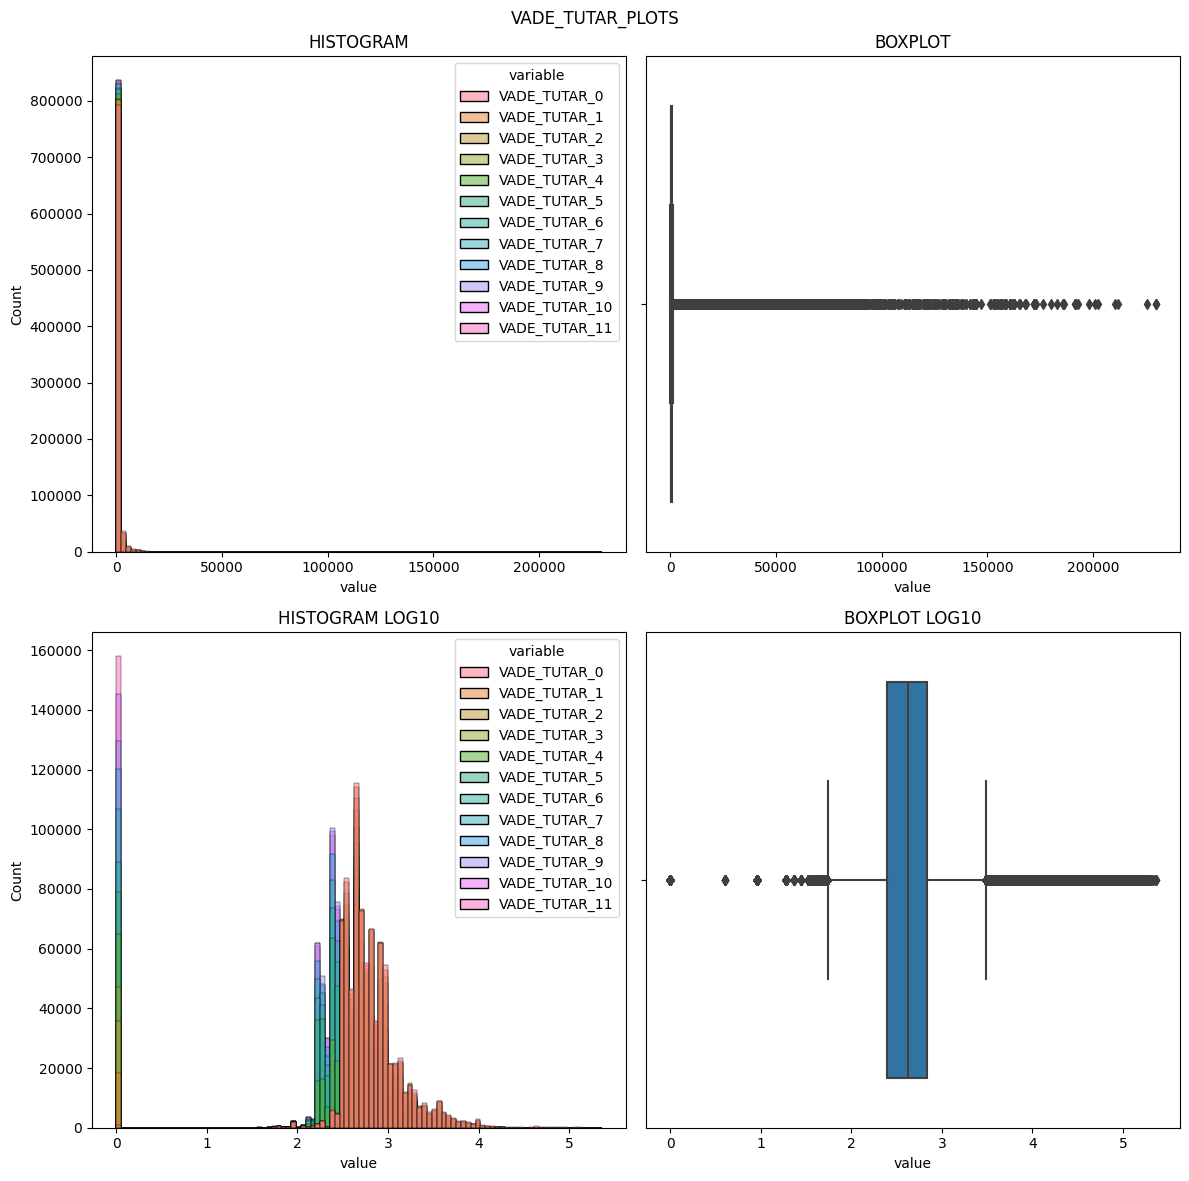

In [9]:
colors = sns.color_palette(n_colors=12)
cols = ["VADE_TUTAR_" + str(i) for i in range(12)]
bins=100
temp_df = train.copy()
for col in cols:
    temp_df[col] = temp_df[col].apply(np.log10)
    temp_df[col] = temp_df[col].replace(-np.inf,0)
    temp_df[col] = temp_df[col].replace(-np.nan,0)
temp_train = pd.melt(train, value_vars=cols)
temp_df = pd.melt(temp_df, value_vars = cols )
f, ax = plt.subplots( nrows = 2, ncols = 2, figsize = (12,12))
ax11, ax12, ax21, ax22 = ax[0][0], ax[0][1], ax[1][0], ax[1][1]
sns.histplot(temp_df, x = 'value', hue = 'variable', color = colors, bins = 100, ax = ax21)
sns.boxplot(temp_df, x= 'value', ax = ax22)
sns.histplot(temp_train, x = 'value', hue = 'variable', color = colors, bins = 100, ax = ax11)
sns.boxplot(temp_train, x= 'value', ax = ax12)
ax11.set_title('HISTOGRAM')
ax12.set_title('BOXPLOT')
ax21.set_title('HISTOGRAM LOG10')
ax22.set_title('BOXPLOT LOG10')
plt.suptitle('VADE_TUTAR_PLOTS')
plt.tight_layout()
plt.show()

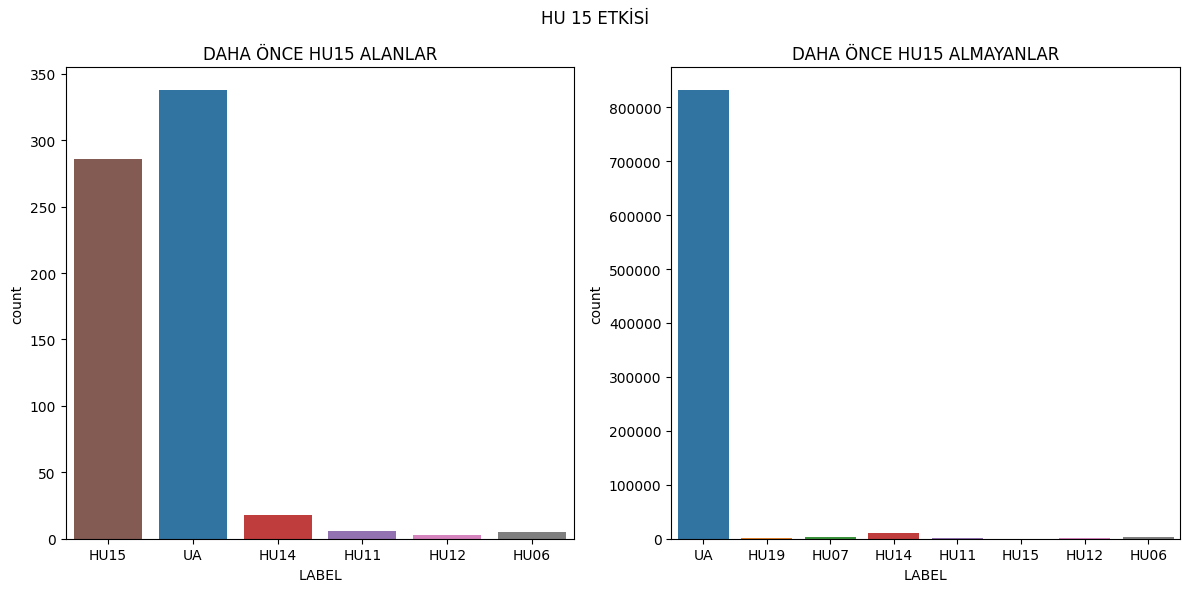

In [10]:
palette = 'tab10'
colors = sns.color_palette(palette = palette, n_colors = train['LABEL'].nunique())
f, ax = plt.subplots( nrows = 1, ncols = 2, figsize = (12,6))
ax11, ax12 = ax[0], ax[1]
sns.countplot(train.loc[train['HU15'] > 0], x = 'LABEL', palette =  [colors[5], colors[0], colors[3], colors[4], colors[6], colors[7]], ax = ax11)
sns.countplot(train.loc[train['HU15'] == 0], x = 'LABEL', palette = colors, ax = ax12)
ax11.set_title('DAHA ÖNCE HU15 ALANLAR')
ax12.set_title('DAHA ÖNCE HU15 ALMAYANLAR')
plt.suptitle('HU 15 ETKİSİ')
plt.tight_layout()
plt.show()

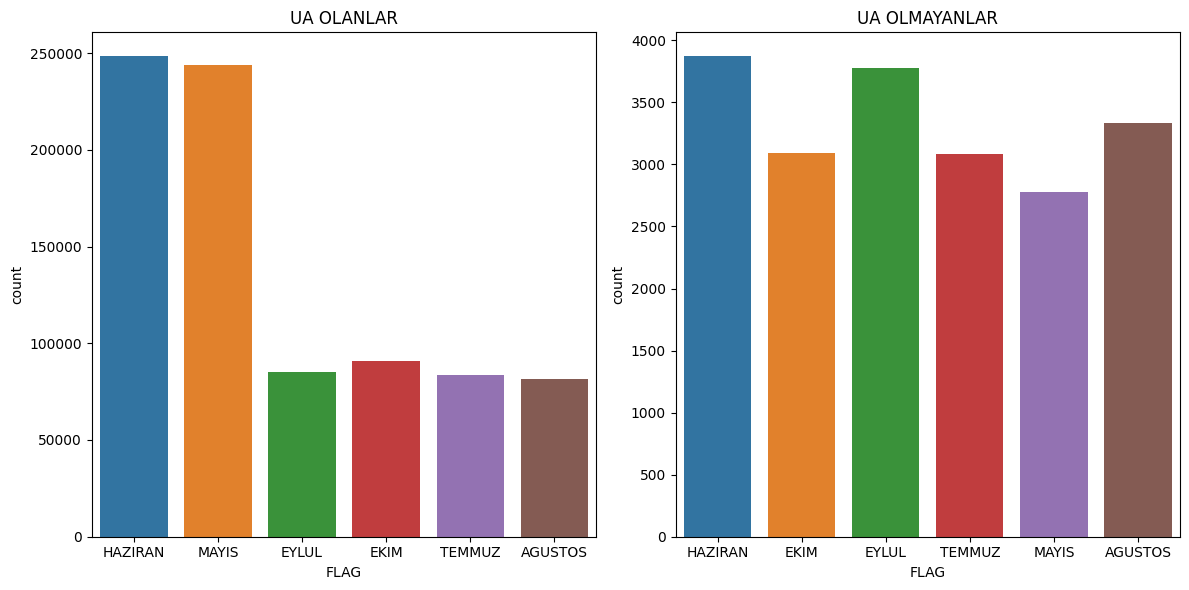

In [11]:
f, ax = plt.subplots( nrows = 1, ncols = 2, figsize= (12,6))
ax11, ax12 = ax[0], ax[1]
sns.countplot(data = train.loc[train['LABEL'] == 'UA'], x = 'FLAG', ax = ax11, palette = 'tab10')
sns.countplot(data = train.loc[train['LABEL'] != 'UA'], x = 'FLAG', ax = ax12, palette = 'tab10')
ax11.set_title('UA OLANLAR')
ax12.set_title('UA OLMAYANLAR')
plt.tight_layout()
plt.show()

In [ ]:
train["ANAPARA_LOG10"] = train["ANAPARA"].apply(np.log10)
train["GETIRI_LOG10"] = train["GETIRI"].apply(np.log10)
f, ax = plt.subplots(1, 2, figsize=(16,6))
sns.histplot(data=train, x="ANAPARA_LOG10", hue="FLAG", ax=ax[0])
sns.histplot(data=train, x="GETIRI_LOG10", hue="FLAG", ax=ax[1])
ax[0].set_title("COL: ANAPARA_LOG10")
ax[1].set_title("COL: GETIRI_LOG10")
plt.show()

In [12]:
categorical_missing_fill = ["PP_MESLEK",
                    "SORU_YATIRIM_KARAKTERI_CVP",
                    "SORU_MEDENI_HAL_CVP",
                    "SORU_EGITIM_CVP"]
numeric_missing_fill = ["SORU_YATIRIM_KARAKTERI_RG",
                    "SORU_MEDENI_HAL_RG",
                    "SORU_EGITIM_RG",
                    "SORU_GELIR_CVP",
                    "SORU_GELIR_RG",
                    "SORU_COCUK_SAYISI_CVP",
                    "SORU_COCUK_SAYISI_RG",
                    "IL"]

In [13]:
log_10_columns = [col for col in train.columns if f'ODEME_' in col or f'VADE_' in col] + ["ANAPARA","GETIRI","SON_SENE_KATKI_MIKTARI",
                           "SON_CEYREK_KATKI_MIKTARI","SON_AY_KATKI_MIKTARI",'total_vade_tutar', 
                           'total_odeme_tutar', 'avg_vade_tutar', 'avg_odeme_tutar']

In [30]:
[f'VADE_TUTAR_{i}' for i in range(12)]

['VADE_TUTAR_0',
 'VADE_TUTAR_1',
 'VADE_TUTAR_2',
 'VADE_TUTAR_3',
 'VADE_TUTAR_4',
 'VADE_TUTAR_5',
 'VADE_TUTAR_6',
 'VADE_TUTAR_7',
 'VADE_TUTAR_8',
 'VADE_TUTAR_9',
 'VADE_TUTAR_10',
 'VADE_TUTAR_11']

In [14]:
class DataPreprocessor:
    def __init__(self, df):
        self.df = df

    def add_payment_features(self):
        self.df['total_vade_tutar'] = self.df[[f'VADE_TUTAR_{i}' for i in range(12)]].sum(axis=1)
        self.df['total_odeme_tutar'] = self.df[[f'ODEME_TUTAR_{i}' for i in range(12)]].sum(axis=1)
        self.df['avg_vade_tutar'] = self.df[[f'VADE_TUTAR_{i}' for i in range(12)]].sum(axis=1) / 12
        self.df['avg_odeme_tutar'] = self.df[[f'ODEME_TUTAR_{i}' for i in range(12)]].sum(axis=1) / 12
        for i in range(12):
            self.df[f'payment_ratio_{i}'] = self.df[f'ODEME_TUTAR_{i}'] / self.df[f'VADE_TUTAR_{i}']
            self.df[f'payment_ratio_{i}'] = self.df[f'payment_ratio_{i}'].replace([-np.nan, -np.inf, np.inf, np.nan], 0)
        self.df['payment_ratio_std'] = self.df[[f'payment_ratio_{i}' for i in range(12)]].std(axis=1)
        self.df['count_full_payments'] = (self.df[[f'payment_ratio_{i}' for i in range(12)]] == 1).sum(axis=1)
        self.df['count_partial_payments'] = ((self.df[[f'payment_ratio_{i}' for i in range(12)]] < 1) & (self.df[[f'payment_ratio_{i}' for i in range(12)]] > 0)).sum(axis=1)
        self.df['count_non_payments'] = (self.df[[f'payment_ratio_{i}' for i in range(12)]] == 0).sum(axis=1)
        return self
    def missing_value(self):
        self.df['SORU_GELIR_CVP'] = self.df['SORU_GELIR_CVP'].str.replace(',', '.')
        self.df[numeric_missing_fill] = self.df[numeric_missing_fill].astype('float64')
        for col in categorical_missing_fill:
            value_counts = self.df[col].value_counts(normalize = True)
            self.df[col] = self.df[col].apply(lambda x: np.random.choice(value_counts.index, p=value_counts.values) if pd.isna(x) else x)
        for col in numeric_missing_fill:
            value_counts = self.df[col].value_counts(normalize = True)
            self.df[col] = self.df[col].apply(lambda x: np.random.choice(value_counts.index, p=value_counts.values) if pd.isna(x) else x)
        self.df['PP_CINSIYET'] = self.df['PP_CINSIYET'] - 1
        return self
    def get_dummy(self):
        dummy = pd.get_dummies(data = self.df['LABEL'], dtype = 'int64', prefix = 'LABEL')
        self.df = pd.concat([self.df,dummy], axis = 1)
        return self
    def log_10_transform(self):
        self.df[log_10_columns] = self.df[log_10_columns].apply(np.log10)
        self.df[log_10_columns] = self.df[log_10_columns].replace([float('inf'), -float('inf'), np.nan, -np.nan], 0)
        return self
    def undersampling_may_june(self):
        haziran_mayis_label_ua = self.df[(self.df['FLAG'].isin(['HAZIRAN', 'MAYIS'])) & (self.df['LABEL_UA'] == 1)]
        other_data = self.df[~((self.df['FLAG'].isin(['HAZIRAN', 'MAYIS'])) & (self.df['LABEL_UA'] == 1))]

        desired_shape = haziran_mayis_label_ua.sample(frac=0.4, random_state=42).shape[0]
        sampled_haziran_mayis_label_ua1 = haziran_mayis_label_ua.loc[haziran_mayis_label_ua["GETIRI"]<2.3,:].sample(int(desired_shape/4), random_state=42)
        sampled_haziran_mayis_label_ua2 = haziran_mayis_label_ua.loc[haziran_mayis_label_ua["GETIRI"]>=2.3,:].sample(int(3*desired_shape/4), random_state=42)

        self.df = pd.concat([sampled_haziran_mayis_label_ua1, sampled_haziran_mayis_label_ua2, other_data])
        return self
    def get_df(self):
        return self.df

In [15]:
test_preporcessor = DataPreprocessor(test)
test_processed = test_preporcessor.add_payment_features()\
                                   .missing_value()\
                                   .log_10_transform()\
                                   .get_df()

In [16]:
train_preporcessor = DataPreprocessor(train)
train_son_hali = train_preporcessor.add_payment_features()\
                                   .missing_value()\
                                   .get_dummy()\
                                   .log_10_transform()\
                                   .undersampling_may_june()\
                                   .get_df()

In [17]:
column_groups = {
    'categorical_columns': [
        "PP_MESLEK",
        "PP_MUSTERI_SEGMENTI",
        "PP_UYRUK",
        "IL",
        "SORU_YATIRIM_KARAKTERI_CVP",
        "SORU_MEDENI_HAL_CVP",
        "SORU_EGITIM_CVP"
    ],
    'binary_columns': [
        'PP_CINSIYET',
        'BU01', 'BU02', 'BU03',
        'BU04', 'BU05', 'BU06', 'BU07', 'BU08', 'BU09', 'BU10', 'BU11', 'BU12',
        'BU13', 'BU14', 'BU15', 'BU16', 'BU17', 'BU18', 'BU19', 'BU20', 'BU21',
        'BU22', 'BU23', 'BU24', 'HU01', 'HU02', 'HU03', 'HU04', 'HU05', 'HU06',
        'HU07', 'HU10', 'HU11', 'HU12', 'HU13', 'HU14', 'HU15', 'HU16', 'HU17',
        'HU18', 'HU19'
    ],
    'numeric_columns': [
        "PP_YAS",
        "SORU_YATIRIM_KARAKTERI_RG",
        "SORU_MEDENI_HAL_RG",
        "SORU_EGITIM_RG",
        "SORU_GELIR_CVP",
        "SORU_GELIR_RG",
        "SORU_COCUK_SAYISI_CVP",
        "SORU_COCUK_SAYISI_RG",
        "BES_AYRILMA_TALEP_ADET",
        "ODEMEME_TALEP_ADET",
        "HAYAT_AYRILMA_TALEP_ADET",
        "BILGI_TALEP_ADET",
        "ANAPARA",
        "GETIRI",
        "AKTIF_ILK_POLICE_RG",
    ],
    'payment_features': [
        'total_vade_tutar',
        'total_odeme_tutar', 'avg_vade_tutar', 'avg_odeme_tutar',
        'payment_ratio_0', 'payment_ratio_1', 'payment_ratio_2',
        'payment_ratio_3', 'payment_ratio_4', 'payment_ratio_5',
        'payment_ratio_6', 'payment_ratio_7', 'payment_ratio_8',
        'payment_ratio_9', 'payment_ratio_10', 'payment_ratio_11',
        'payment_ratio_std', 'count_full_payments', 'count_partial_payments','count_non_payments'
    ],
    'external_features': [
        'ANAPARA_usd','GETIRI_usd','ANAPARA_bist100_ratio','GETIRI_bist100_ratio',
        'USD_TRY_Avg','BIST_100_Avg'
    ],
    'target_labels': [
        'LABEL_HU06', 'LABEL_HU07', 'LABEL_HU11', 'LABEL_HU12',
        'LABEL_HU14', 'LABEL_HU15', 'LABEL_HU19'
    ]
}

In [69]:
train_son_hali['IL'] = train_son_hali['IL'].astype('object')
train_son_hali['PP_MUSTERI_SEGMENTI'] = train_son_hali['PP_MUSTERI_SEGMENTI'].astype('object')
train_son_hali['PP_UYRUK'] = train_son_hali['PP_UYRUK'].astype('object')
train_son_hali[column_groups["categorical_columns"]] = train_son_hali[column_groups["categorical_columns"]].astype('str')

In [119]:
test_processed['IL'] = test_processed['IL'].astype('object')
test_processed['PP_MUSTERI_SEGMENTI'] = test_processed['PP_MUSTERI_SEGMENTI'].astype('object')
test_processed['PP_UYRUK'] = test_processed['PP_UYRUK'].astype('object')
test_processed[column_groups["categorical_columns"]] = test_processed[column_groups["categorical_columns"]].astype('str')

In [8]:
training_columns = column_groups["categorical_columns"] + column_groups["binary_columns"] + column_groups["numeric_columns"] + column_groups["payment_features"]

for label in column_groups['target_labels']:
    print("="*30, label, "="*30)

    import pandas as pd
    from sklearn.model_selection import KFold, train_test_split, StratifiedGroupKFold
    from sklearn.metrics import f1_score, average_precision_score
    from catboost import CatBoostClassifier, Pool
    from sklearn.calibration import CalibratedClassifierCV
    import numpy as np
    import matplotlib.pyplot as plt
    
    may_june_data = train_son_hali[train_son_hali['FLAG'].isin(['MAYIS', 'HAZIRAN'])]        
    non_may_june = train_son_hali[train_son_hali['FLAG'].isin(['MAYIS', 'HAZIRAN'])]

    oof_data, non_oof_train_data = train_test_split(non_may_june, test_size=0.9, 
                                                    stratify=non_may_june[label],random_state = 42)
    
    train_data = pd.concat([non_oof_train_data, may_june_data])
    
    month_order = ['MAYIS', 'HAZIRAN', 'TEMMUZ', 'AGUSTOS', 'EYLUL', 'EKIM']
    train_data['FLAG'] = pd.Categorical(train_data['FLAG'], categories=month_order, ordered=True)

    train_data = train_data.sort_values(["FLAG","MUSTERI_ID"])

    kf = KFold(n_splits=10)
    
    pr_aucs = []
    fold_f1_scores = []
    thresholds = np.linspace(0, 1, 200)
    weights = [1,1,1,1.5,1.5,1.5,2,2,2,2.2]       
    
    for fold, (train_index, test_index) in enumerate(kf.split(train_data[training_columns]), 1):     
        print("*" * 50)
        print(f"FOLD: {fold}")

        X_train_fold, X_test_fold = train_data.iloc[train_index], train_data.iloc[test_index]
        y_train_fold, y_test_fold = X_train_fold[label], X_test_fold[label]

        positive_ratio = X_test_fold[label].mean()  

        print(f"Fold {fold}: Positive Class Ratio = {positive_ratio:.4f}")


        train_pool = Pool(X_train_fold[training_columns],
                          y_train_fold, cat_features=column_groups["categorical_columns"])
        test_pool = Pool(X_test_fold[training_columns],
                         y_test_fold, cat_features=column_groups["categorical_columns"])

        model = CatBoostClassifier(learning_rate=0.175, task_type='GPU', cat_features=column_groups["categorical_columns"], iterations=1000, verbose=100, random_state=42)
        model.fit(train_pool, eval_set=test_pool)

        calibrated_model = CalibratedClassifierCV(estimator=model, method='sigmoid', cv='prefit')
        calibrated_model.fit(X_train_fold[training_columns], y_train_fold)

        y_pred_proba = calibrated_model.predict_proba(X_test_fold[training_columns])[:, 1]

        pr_auc = average_precision_score(y_test_fold, y_pred_proba)
        pr_aucs.append(pr_auc)

        fold_f1 = [f1_score(y_test_fold, y_pred_proba >= threshold) for threshold in thresholds]
        fold_f1_scores.append(fold_f1)

        plt.figure(figsize=(10, 6))
        plt.plot(thresholds, fold_f1, label=f'Fold {fold} F1 Scores')
        plt.xlabel('Threshold')
        plt.ylabel('F1 Score')
        plt.title(f'F1 Score by Threshold for Fold {fold}')
        plt.xticks(np.arange(0, 1.05, 0.1), fontsize=8)  
        plt.yticks(fontsize=8)  
        plt.minorticks_on()  
        plt.grid(True, which='major', linestyle='-', linewidth=0.5)  
        plt.grid(True, which='minor', linestyle='--', linewidth=0.5)  
        plt.legend()
        plt.show()
        print(f"PR AUC for fold {fold}: {pr_auc:.4f}")

    weighted_average_pr_auc = np.average(pr_aucs, weights=weights)
    weighted_fold_f1_scores = np.average(fold_f1_scores, axis=0, weights=weights)       # weightsler neden farklı ?
    optimal_threshold_weighted = thresholds[np.argmax(weighted_fold_f1_scores)]

    oof_pred = calibrated_model.predict_proba(oof_data[training_columns])[:, 1]
    oof_pr_auc = average_precision_score(oof_data[label], oof_pred)
    oof_f1_score = f1_score(oof_data[label], oof_pred >= optimal_threshold_weighted)

    print(f"\nWeighted Average PR AUC across folds: {weighted_average_pr_auc:.4f}")
    print(f"Optimal Threshold (Weighted): {optimal_threshold_weighted:.2f}")
    print(f"PR AUC for OOF Data: {oof_pr_auc:.4f}")
    print(f"F1 Score for OOF Data at Optimal Threshold: {oof_f1_score:.4f}")

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, np.mean(fold_f1_scores, axis=0), label='Average F1 Scores from CV')
    plt.axvline(x=optimal_threshold_weighted, color='r', linestyle='--', label=f'Optimal Threshold (Weighted): {optimal_threshold_weighted:.2f}')
    plt.scatter(optimal_threshold_weighted, oof_f1_score, color='g', marker='o', label='F1 Score on OOF Data')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.title('Comparison of F1 Score by Threshold')
    plt.xticks(np.arange(0, 1.05, 0.1), fontsize=8)  
    plt.yticks(fontsize=8)  
    plt.minorticks_on()  
    plt.grid(True, which='major', linestyle='-', linewidth=0.5) 
    plt.grid(True, which='minor', linestyle='--', linewidth=0.5)  
    plt.legend()
    plt.show()

NameError: name 'column_groups' is not defined

In [80]:
F1_scores_for_oof = {
    'HU06' : 0.2270,
    'HU07' : 0.3271,
    'HU11' : 0.0976,
    'HU12' : 0.0727,
    'HU14' : 0.4297,
    'HU15' : 0.7111,
    'HU19' : 0.2623
}

In [101]:
train_son_hali[column_groups["categorical_columns"]] = train_son_hali[column_groups["categorical_columns"]].astype(str)

In [120]:
X_test = test_processed.iloc[:][training_columns]

In [121]:
X_test[column_groups["categorical_columns"]] = X_test[column_groups["categorical_columns"]].astype(str)

In [122]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV

training_columns = column_groups["categorical_columns"] + column_groups["binary_columns"] + column_groups["numeric_columns"] + column_groups["payment_features"]

X_test = test_processed.iloc[:][training_columns]

for label in column_groups['target_labels']:
    
    print("="*25, f"Training {label}", "="*25)
    
    X_train = train_son_hali.iloc[:][training_columns]
    y_train = train_son_hali.iloc[:][label]
    
    train_pool = Pool(X_train, y_train, cat_features=column_groups["categorical_columns"])

    model = CatBoostClassifier(learning_rate = 0.175732, cat_features=column_groups["categorical_columns"], iterations = 1000, 
                               verbose = 100, random_state=42)

    model.fit(train_pool)
    
    calibrated_model = CalibratedClassifierCV(estimator=model, method='sigmoid', cv='prefit')
    calibrated_model.fit(X_train, y_train)
    
    test_processed[label] = calibrated_model.predict_proba(X_test)[:,1]
    
    print("")

========================= Training LABEL_HU06 =========================
0:	learn: 0.3371727	total: 1.36s	remaining: 22m 36s
100:	learn: 0.0264653	total: 1m 4s	remaining: 9m 33s
200:	learn: 0.0254068	total: 1m 43s	remaining: 6m 52s
300:	learn: 0.0245223	total: 2m 23s	remaining: 5m 32s
400:	learn: 0.0238429	total: 3m 2s	remaining: 4m 32s
500:	learn: 0.0231049	total: 3m 41s	remaining: 3m 40s
600:	learn: 0.0226179	total: 4m 20s	remaining: 2m 52s
700:	learn: 0.0220819	total: 5m	remaining: 2m 8s
800:	learn: 0.0215866	total: 5m 40s	remaining: 1m 24s
900:	learn: 0.0211022	total: 6m 18s	remaining: 41.6s
999:	learn: 0.0206208	total: 7m 3s	remaining: 0us

========================= Training LABEL_HU07 =========================
0:	learn: 0.2671546	total: 449ms	remaining: 7m 28s
100:	learn: 0.0219625	total: 42.5s	remaining: 6m 18s
200:	learn: 0.0209236	total: 1m 24s	remaining: 5m 37s
300:	learn: 0.0200654	total: 2m 30s	remaining: 5m 49s
400:	learn: 0.0194449	total: 3m 41s	remaining: 5m 30s
500:	lear

In [123]:
conditions = [
    test_processed['LABEL_HU15'] > 0.02,
    test_processed['LABEL_HU11'] > 0.04,
    test_processed['LABEL_HU12'] > 0.01, 
    test_processed['LABEL_HU19'] > 0.01,  
    test_processed['LABEL_HU06'] > 0.04,  
    test_processed['LABEL_HU07'] > 0.04,  
    test_processed['LABEL_HU14'] > 0.07
]

choices = ['HU15', 
           'HU11', 'HU12', 'HU19', 'HU06', 'HU07','HU14']

test_processed['LABEL'] = np.select(conditions, choices, default='UA')

def post_process(test_df):
    
    test_df["PP_YAS"] = test_df["PP_YAS"]/12
    test_df.loc[(test_df["LABEL"]=="HU06") & (test_df["PP_YAS"]>70),"LABEL"] = "UA"
    test_df.loc[(test_df["LABEL"]=="HU07") & ((test_df["PP_YAS"]<18) | (test_df["PP_YAS"]>50)),"LABEL"] = "UA"
    test_df.loc[(test_df["LABEL"]=="HU11") & ((test_df["PP_YAS"]<18) | (test_df["PP_YAS"]>50)),"LABEL"] = "UA"
    test_df.loc[(test_df["LABEL"]=="HU12") & ((test_df["PP_YAS"]<18) | (test_df["PP_YAS"]>69)),"LABEL"] = "UA"
    test_df.loc[(test_df["LABEL"]=="HU14") & ((test_df["PP_YAS"]<18) | (test_df["PP_YAS"]>69)),"LABEL"] = "UA"
    test_df.loc[(test_df["LABEL"]=="HU15") & ((test_df["PP_YAS"]<18) | (test_df["PP_YAS"]>60)),"LABEL"] = "UA"
    test_df.loc[(test_df["LABEL"]=="HU19") & ((test_df["PP_YAS"]<18) | (test_df["PP_YAS"]>65)),"LABEL"] = "UA"
    
    return test_df

In [124]:
test_processed = post_process(test_processed)

In [126]:
test_processed[["MUSTERI_ID","LABEL"]].to_csv("deneme_lo.csv",index=False)